In [84]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import OCO_v11MIP_analysis as oco
from matplotlib.colors import BoundaryNorm

In [2]:
print(oco.get_region_list())
print(oco.get_tm5_model_list())
print(oco.get_gc_model_list())

{1: 'North American Boreal', 2: 'North American Temperate', 3: 'South American Tropical', 4: 'South American Temperate', 5: 'Northern Africa', 6: 'Southern Africa', 7: 'Eurasia Boreal', 8: 'Eurasia Temperate', 9: 'Tropical Asia', 10: 'Australia', 11: 'Europe', 12: 'North Pacific Temperate', 13: 'West Pacific Tropical', 14: 'East Pacific Tropical', 15: 'South Pacific Temperate', 16: 'Northern Ocean', 17: 'North Atlantic Temperate', 18: 'Atlantic Tropical', 19: 'South Atlantic Temperate', 20: 'Southern Ocean', 21: 'Indian Tropical', 22: 'South Indian Temperate', 23: 'Not optimized'}
['WOMBAT-TM5', 'TM5-4DVAR', 'CT-MP', 'CT']
['WOMBAT-GC', 'JHU', 'GCAS', 'CMS-Flux', 'Ames']


In [144]:
def make_plots(REGION, obs):

    # ------- TM5 total line plot -------
    ens_tm5 = oco.get_tm5_ensemble(obs)['land_flux']
    ens_tm5_total, ens_tm5_gridded = oco.region_aggregate(ens_tm5, REGION, return_gridded=True)
    
    plt.figure(figsize=(15,5))
    for model in oco.get_tm5_model_list():
        plt.plot(ens_tm5_total.sel(model=model).time, ens_tm5_total.sel(model=model), label=model)
    plt.grid()
    plt.legend()
    plt.ylabel('Land Flux  [Pg C / year]')
    plt.title('TM5, {}, {}'.format(obs, oco.get_region_list()[REGION]))

    # ------- TM5 maps -------
    levels = np.array([0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1])
    levelsc = np.array([0.01])
    levels = np.hstack([-levels[::-1], [0], levels])
    levelsc = np.hstack([-levelsc[::-1], levelsc])
    norm = BoundaryNorm(levels, ncolors=256, clip=True)
    cmap = 'turbo'
    
    fig = plt.figure(figsize=(6,6))
    for i,model in enumerate(oco.get_tm5_model_list()):
        flux = ens_tm5_gridded.sel(model=model)
        flux = flux.where(~np.isnan(flux), drop=True)
        ax = fig.add_subplot(2,2,i+1)
        cf = ax.contourf(flux.lon, flux.lat, flux.mean('time'), levels=levels, 
                         cmap=cmap, norm=norm)
        #ax.contour(flux.lon, flux.lat, flux.mean('time'), levels=levelsc, colors='k')
        ax.set_title(model)
    fig.suptitle('TM5, {}, {}'.format(obs, oco.get_region_list()[REGION]))
    cbar =  fig.colorbar(cf, ax=plt.gcf().axes, location='top', pad=0.07, fraction=0.05,
                         label = 'Land Flux  [Pg C / year]')

    # ------- GC total line plot -------
    ens_gc = oco.get_gc_ensemble(obs)['land_flux']
    ens_gc_total, ens_gc_gridded = oco.region_aggregate(ens_gc, REGION, return_gridded=True)
    
    plt.figure(figsize=(15,5))
    for model in oco.get_gc_model_list():
        plt.plot(ens_gc_total.sel(model=model).time, ens_gc_total.sel(model=model), label=model)
    plt.grid()
    plt.legend()
    plt.ylabel('Land Flux  [Pg C / year]')
    plt.title('GC, {}, {}'.format(obs, oco.get_region_list()[REGION]))

    # ------- GC maps -------
    fig = plt.figure(figsize=(9,6))
    for i,model in enumerate(oco.get_gc_model_list()):
        flux = ens_gc_gridded.sel(model=model)
        flux = flux.where(~np.isnan(flux), drop=True)
        ax = fig.add_subplot(2,3,i+1)
        cf = ax.contourf(flux.lon, flux.lat, flux.mean('time'), levels=levels, 
                         cmap=cmap, norm=norm)
        #ax.contour(flux.lon, flux.lat, flux.mean('time'), levels=levelsc, colors='k')
        ax.set_title(model)
    fig.suptitle('GC, {}, {}'.format(obs, oco.get_region_list()[REGION]))
    cbar = fig.colorbar(cf, ax=plt.gcf().axes, location='top', pad=0.07, fraction=0.05, 
                       label = 'Land Flux  [Pg C / year]')

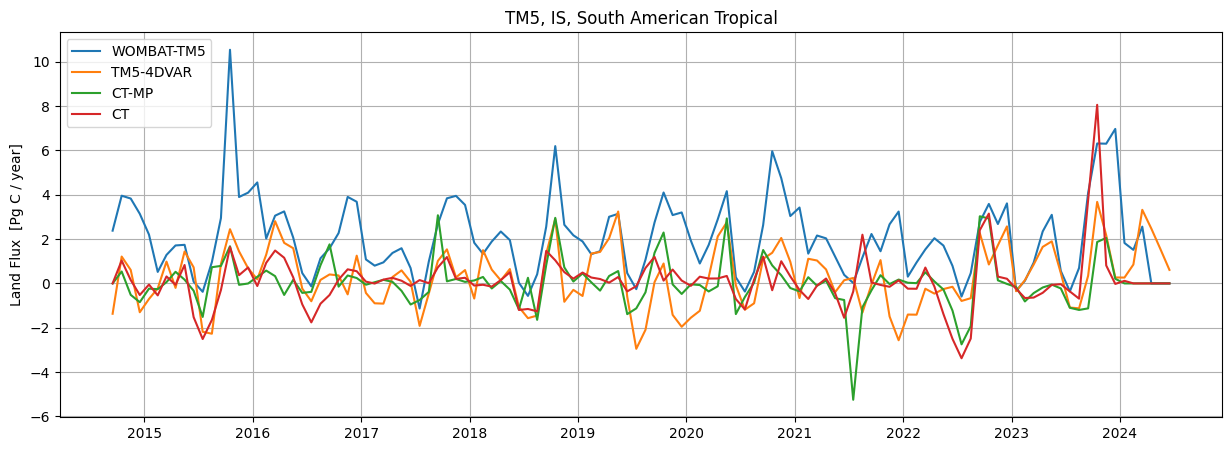

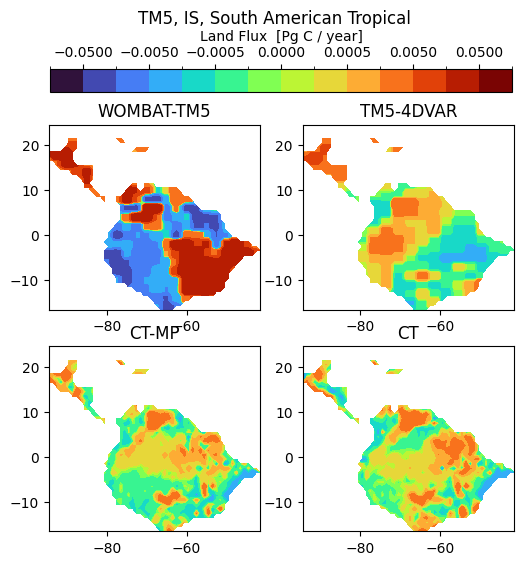

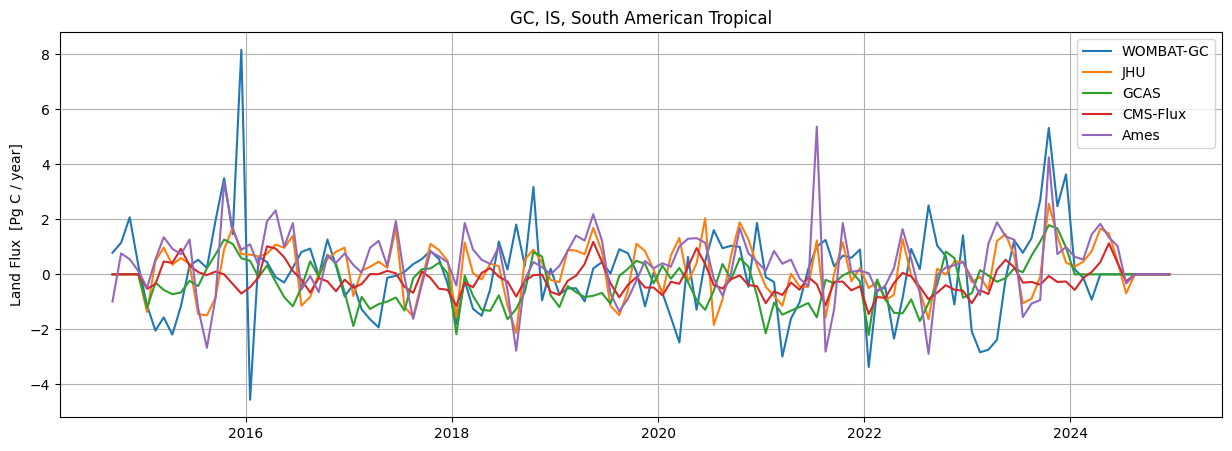

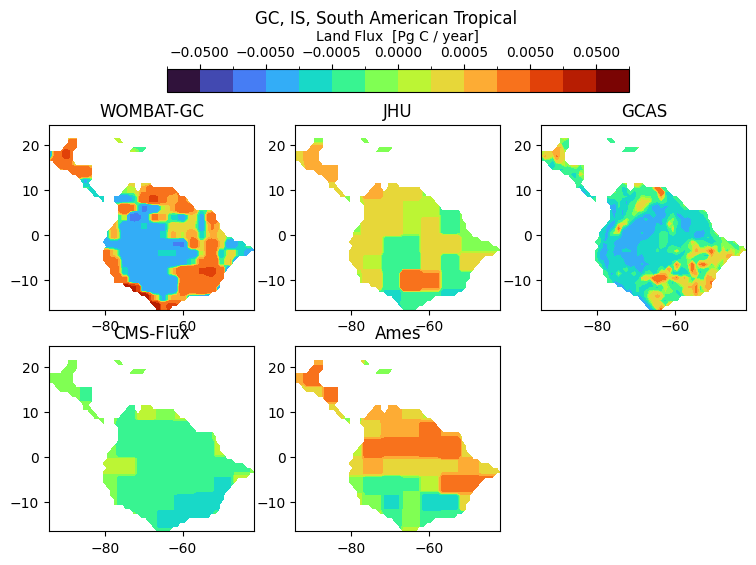

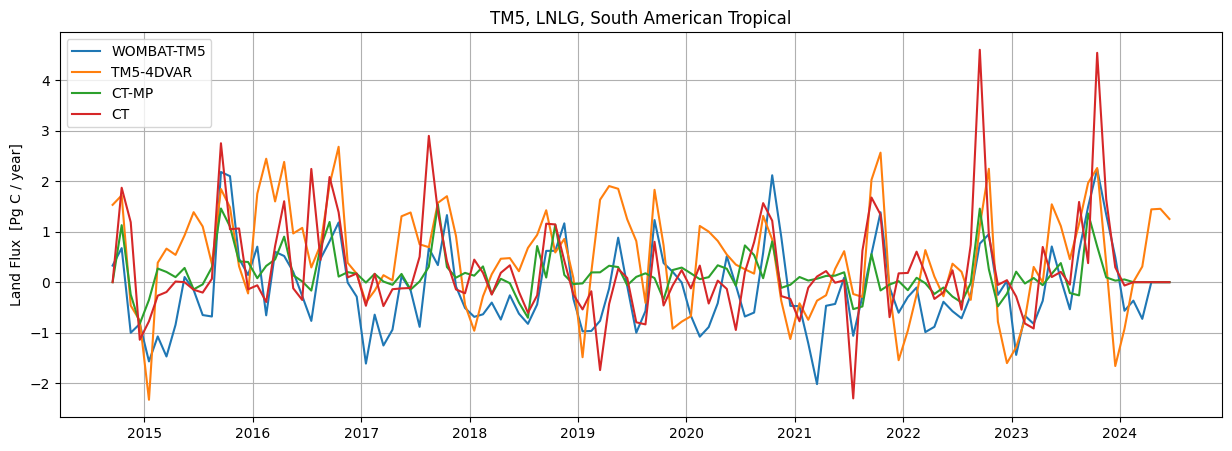

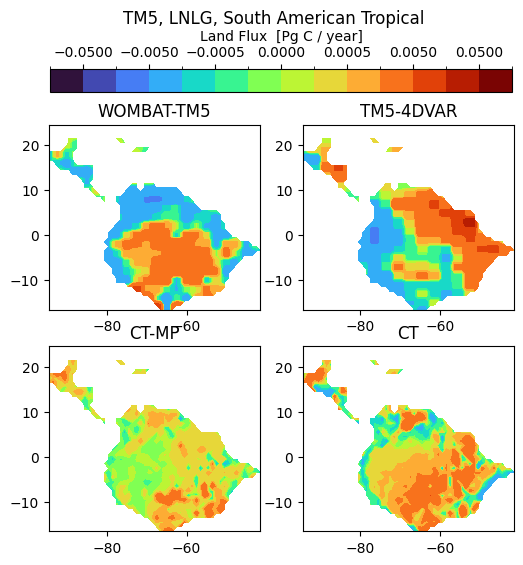

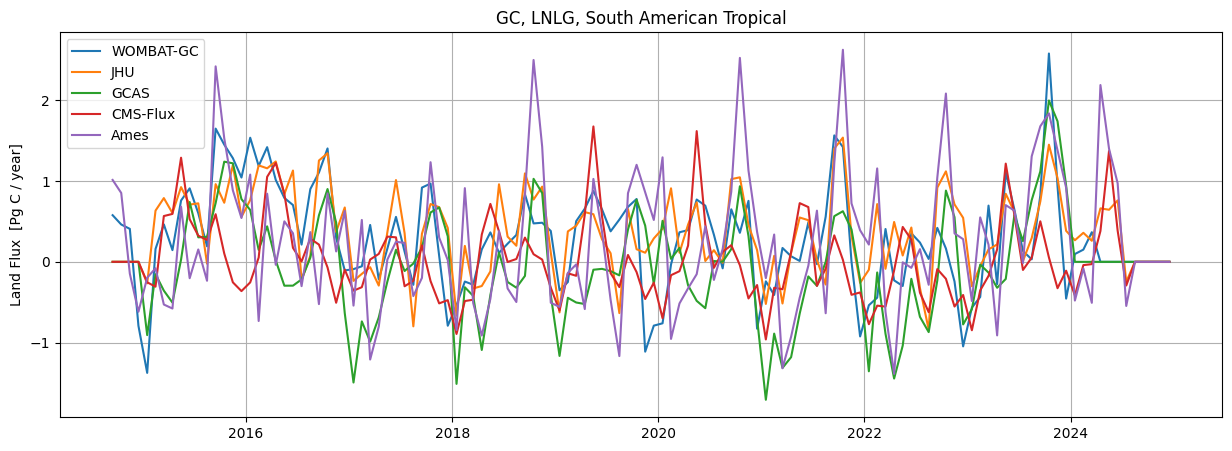

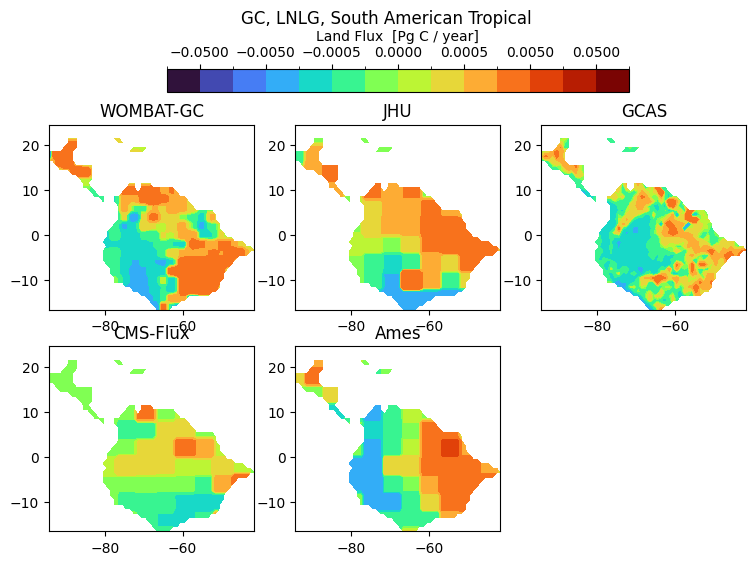

In [154]:
make_plots(3, 'IS') #SA Tropical
make_plots(3, 'LNLG') #SA Tropical

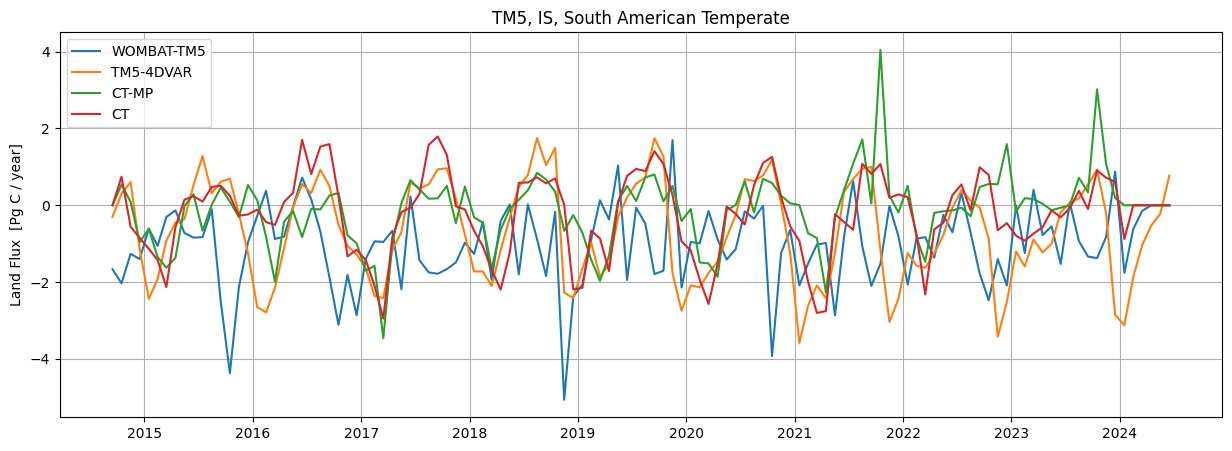

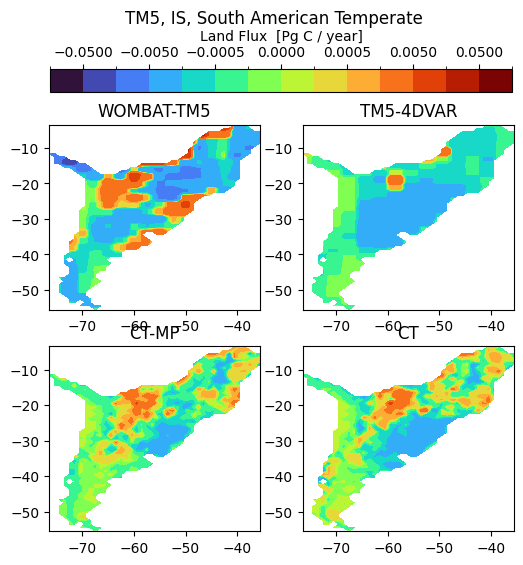

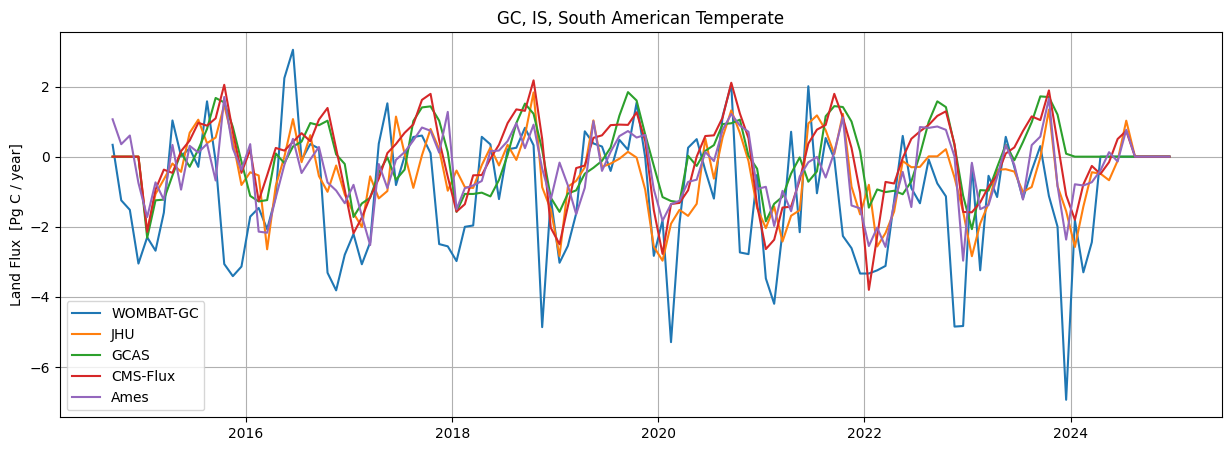

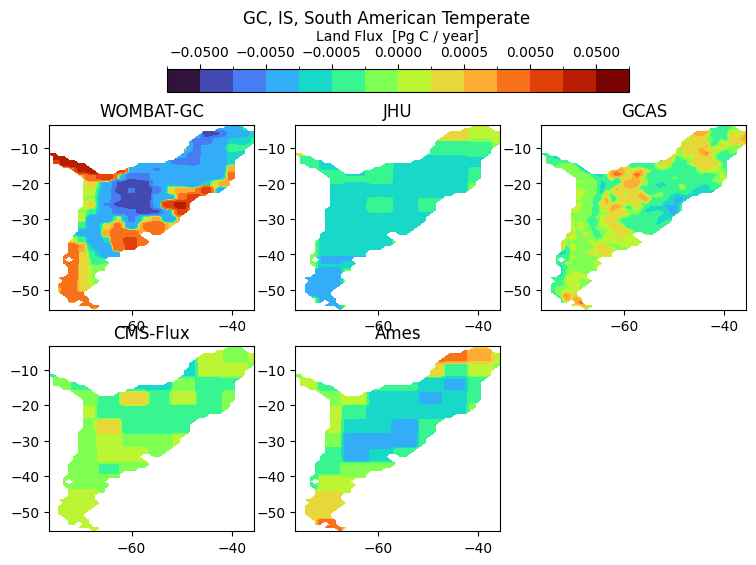

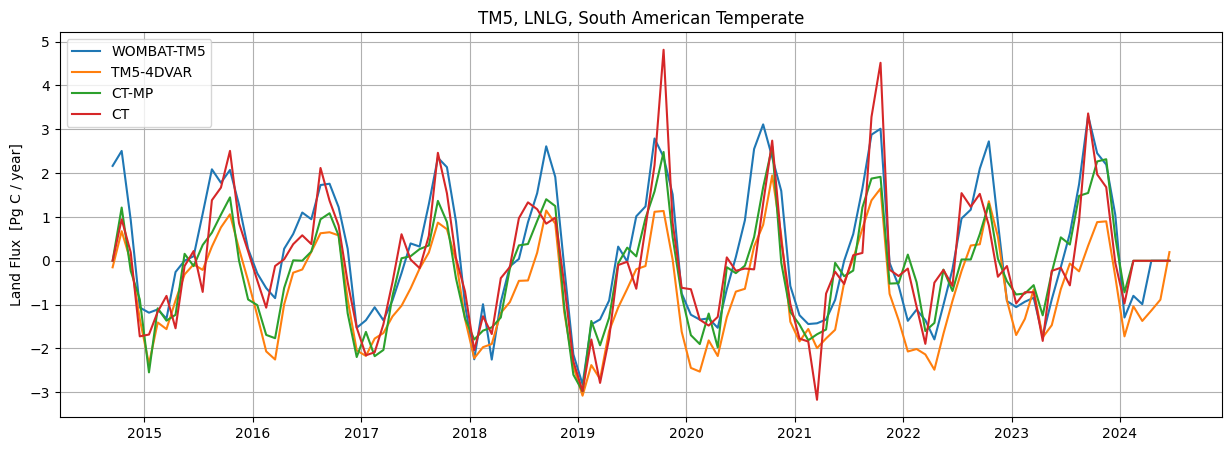

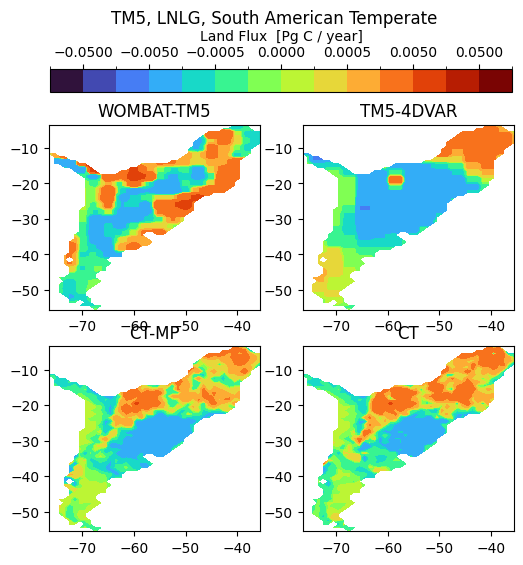

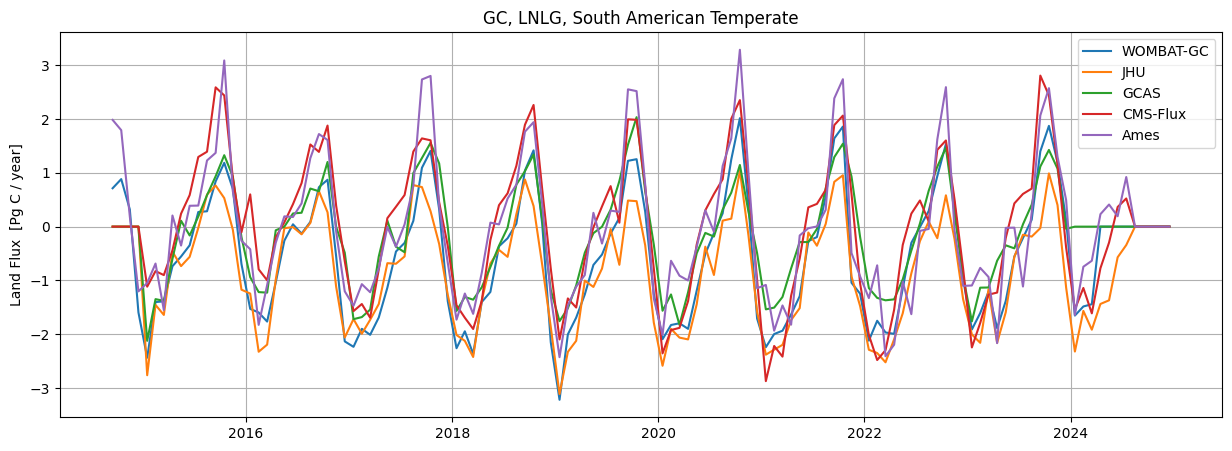

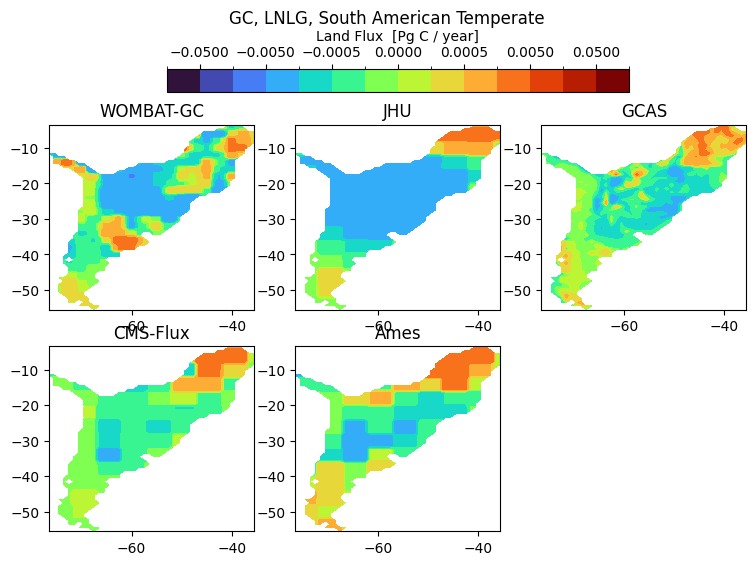

In [155]:
make_plots(4, 'IS') #SA Temperate
make_plots(4, 'LNLG') #SA Temperate

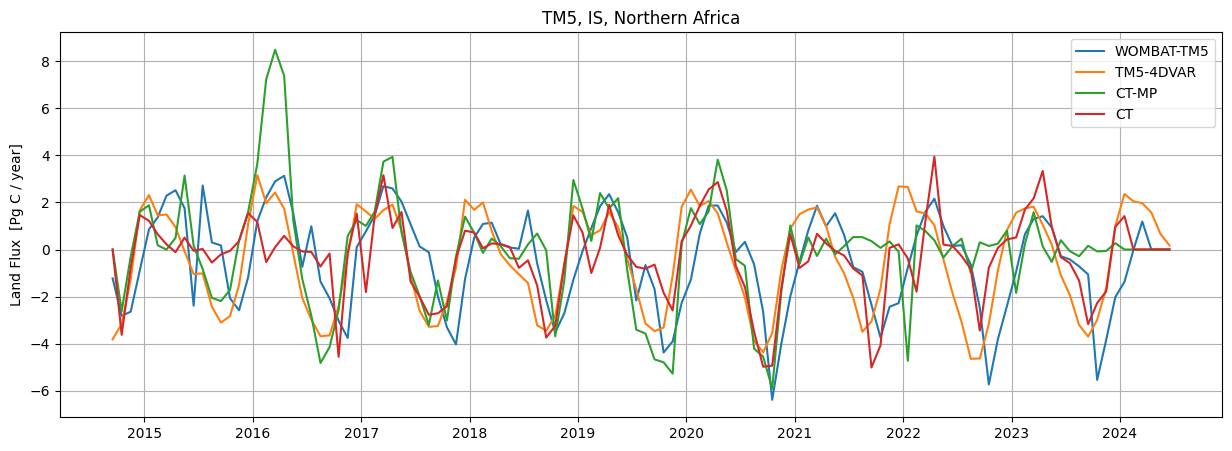

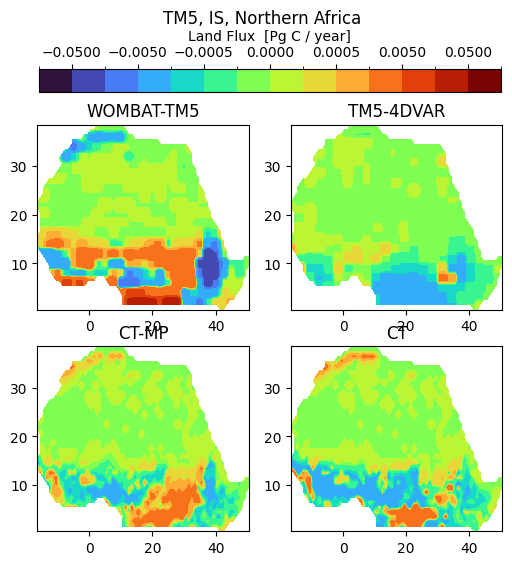

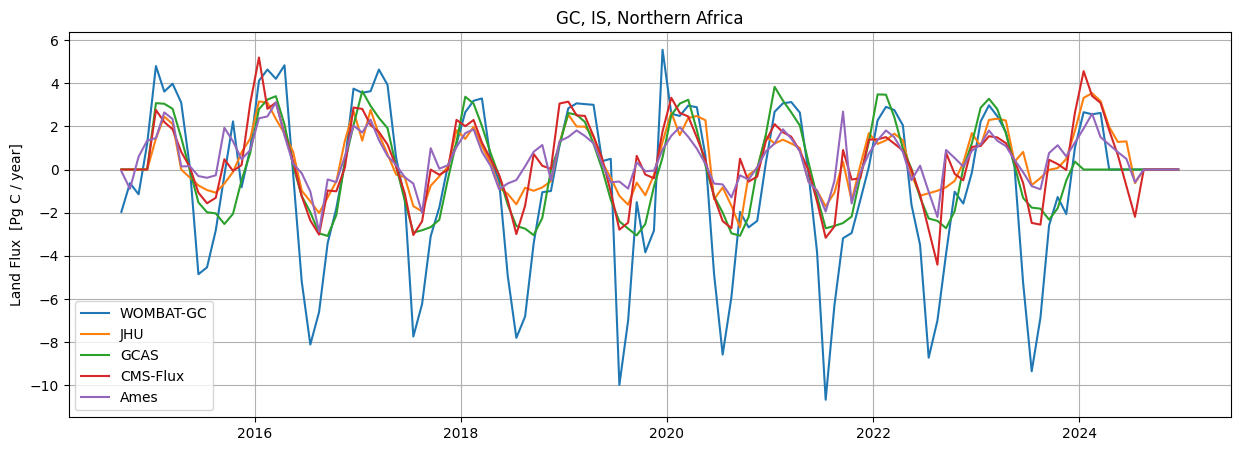

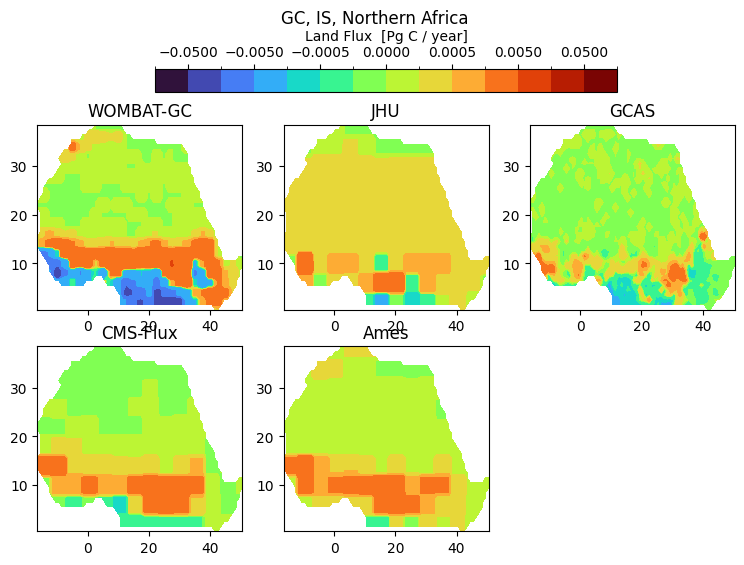

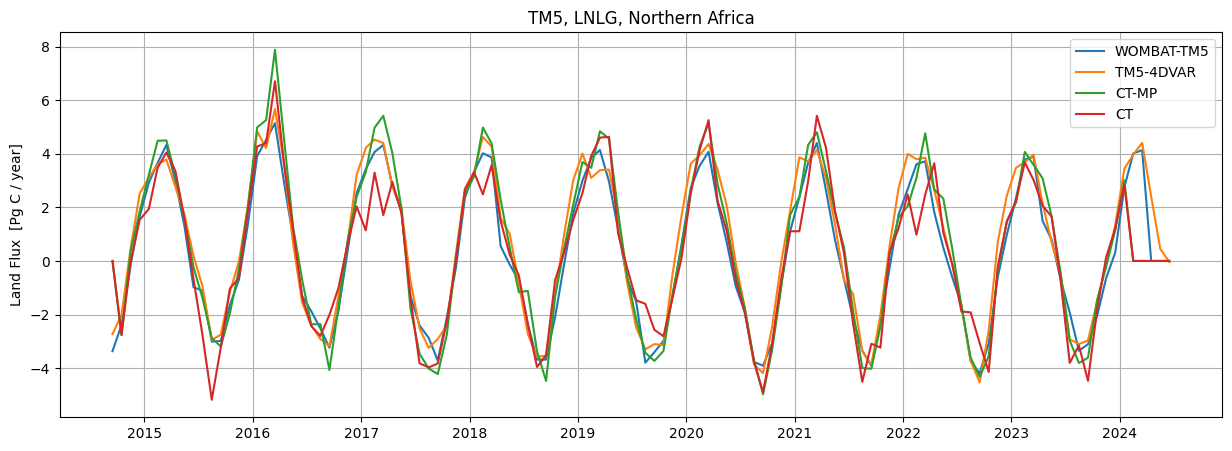

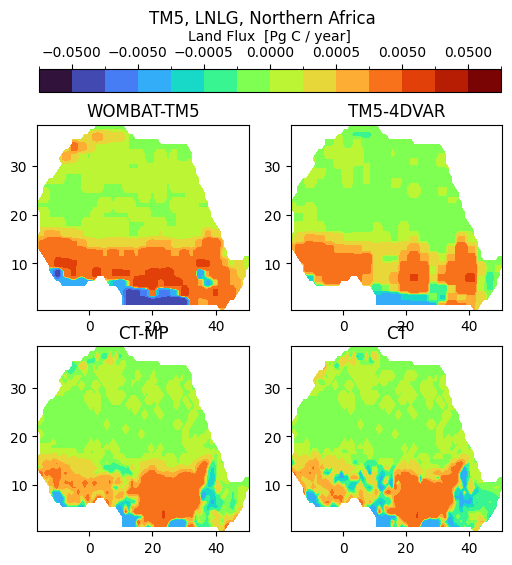

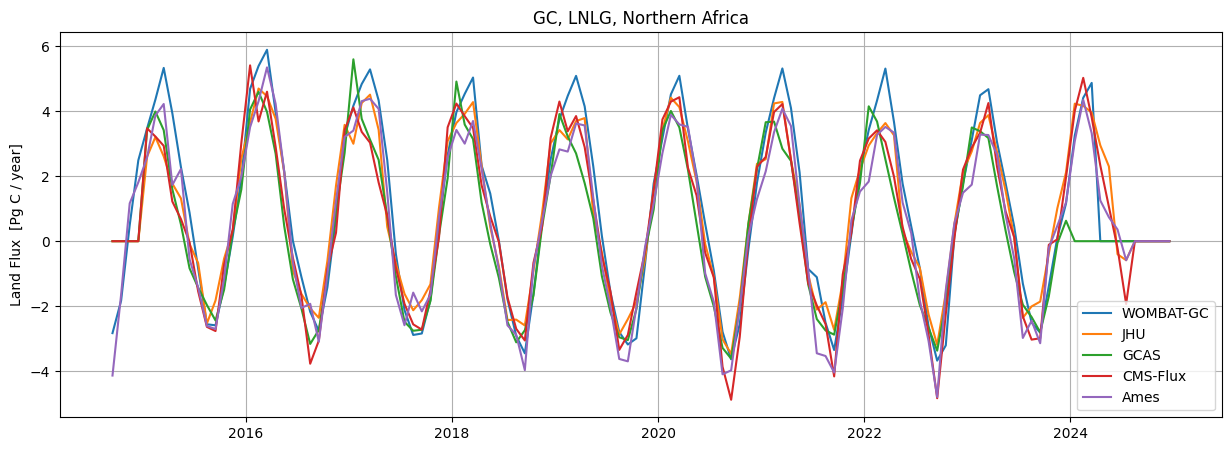

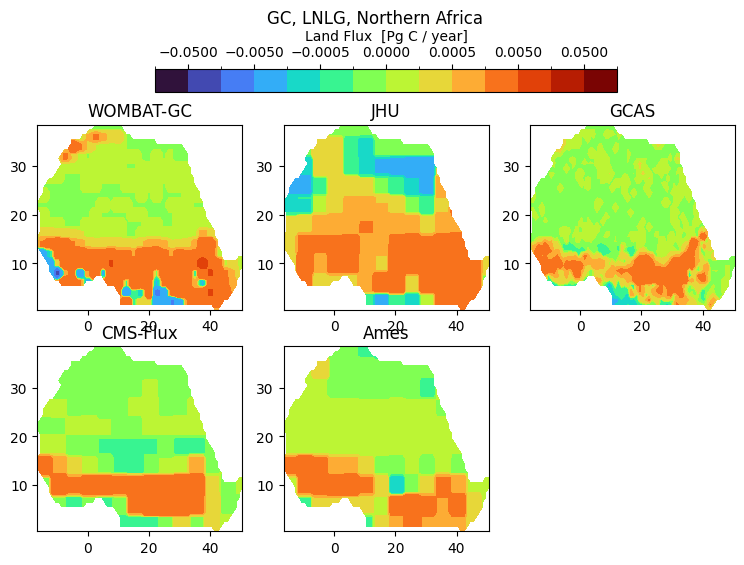

In [156]:
make_plots(5, 'IS') #Northern Africa
make_plots(5, 'LNLG') #Northern Africa

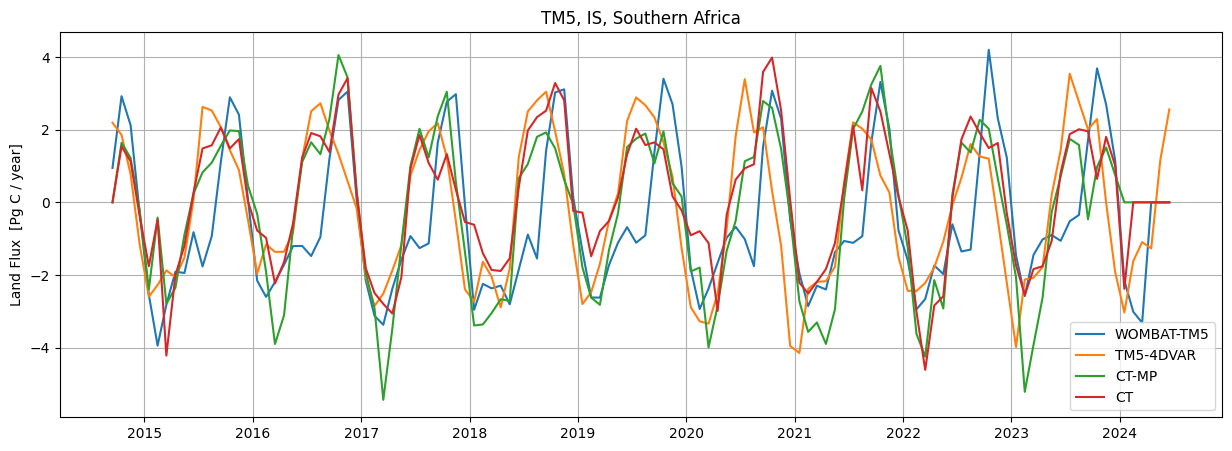

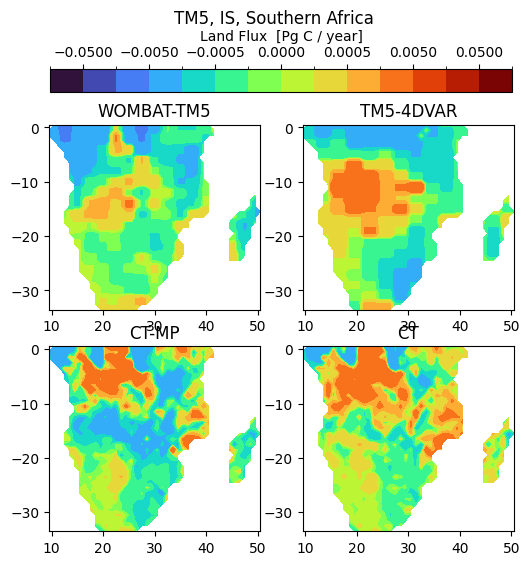

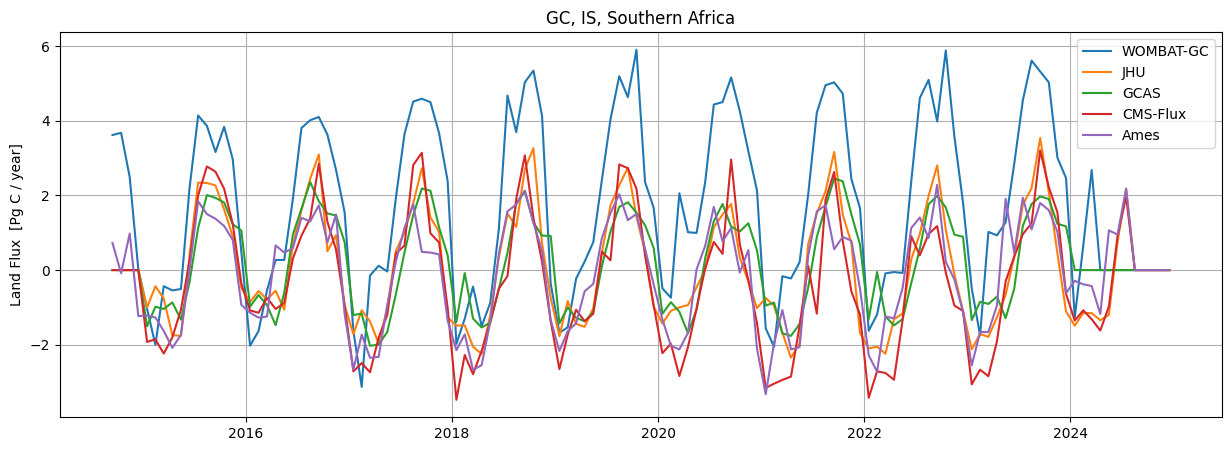

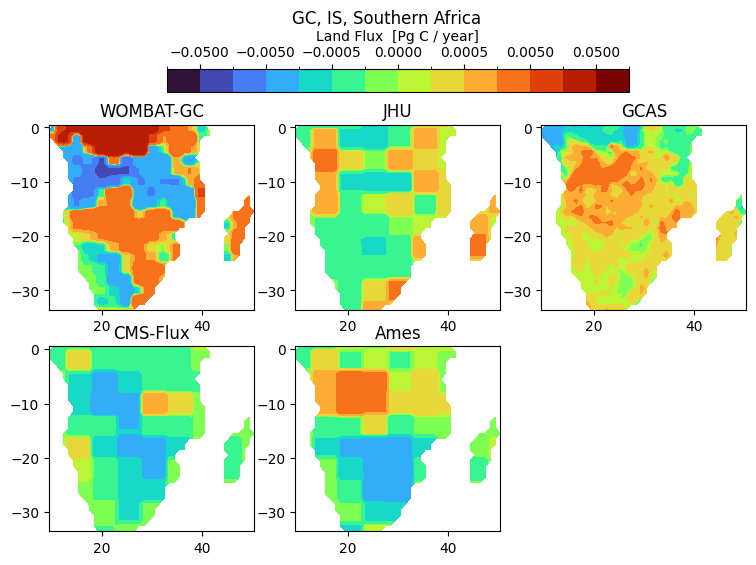

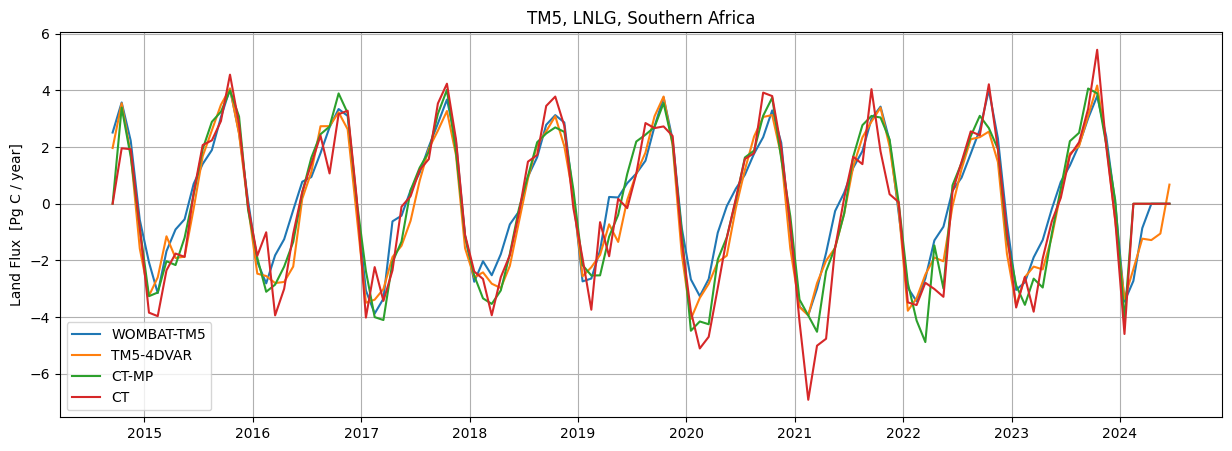

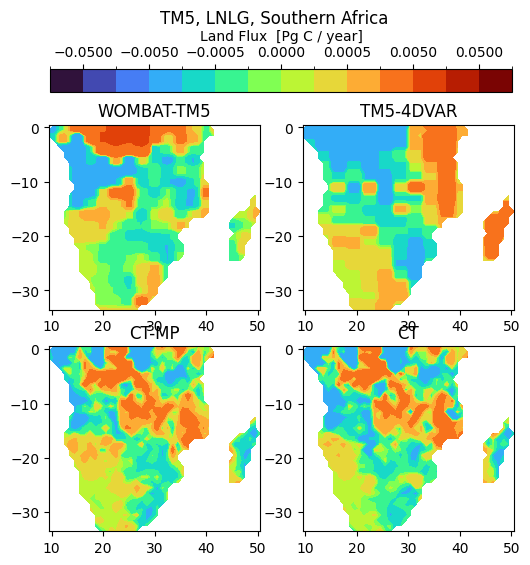

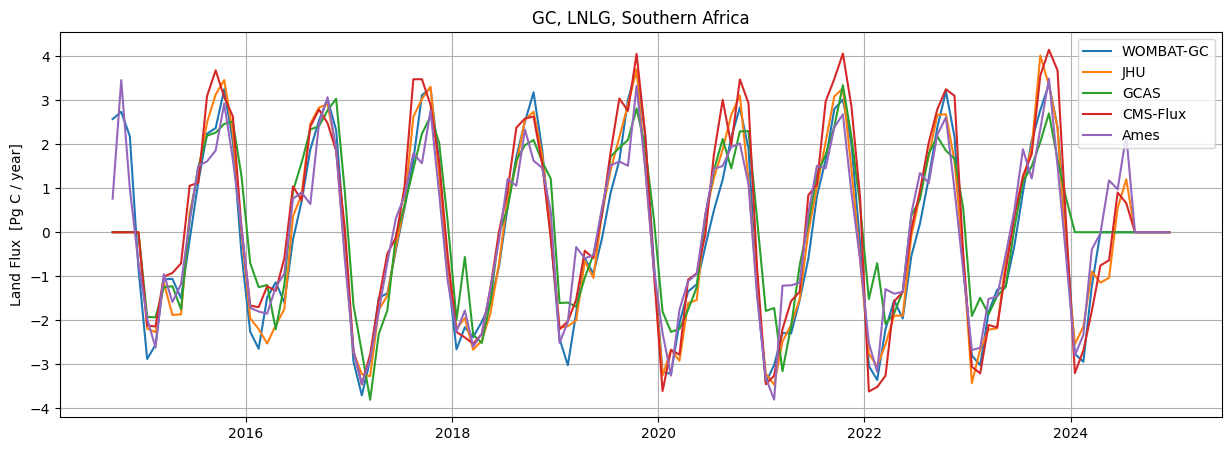

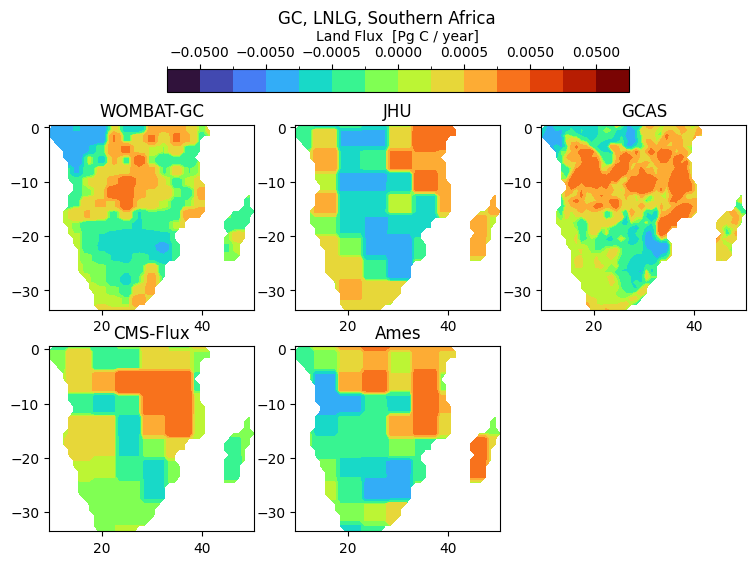

In [157]:
make_plots(6, 'IS') #S Africa
make_plots(6, 'LNLG') #S Africa